# Self-Normalization Analysis (Supplemental Fig. S1)

Validates the self-normalizing property of the CLP-SNN learning rule by measuring
how closely the learned prototype tracks the cluster center across three synthetic
dimensions (d = 64, 256, 1280) and on real EfficientNet-B0 OpenLORIS features.

**Three learning-rule variants:**

| Variant | Rule | Label |
|---|---|---|
| **A** | `Dw = a*x`, then `w <- w/norm(w)` | CLP |
| **B** | `Dw = a*(x - y*w)`, no renorm | CLP-SNN (Float) |
| **F** | INT32 MAC, FLOOR shift, shared-scalar SR | CLP-SNN (INT8) |

**Figure layout (3 rows x 4 cols):**
- Row 0 -- cosine similarity of w to cluster center
- Row 1 -- weight-vector norm ||w||
- Row 2 -- raw dot product w * center

The full reference implementation is in `analysis/self_norm_analysis.py`.
Run it directly to regenerate the figure:
```bash
python analysis/self_norm_analysis.py
```
This notebook walks through the experiment inline at the same scale.

In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch

REPO = Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

IMAGES_DIR = REPO / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'lines.linewidth': 1,
    'axes.linewidth': 0.75,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'savefig.dpi': 600,
})

## Learning rule variants

All variants update a single weight vector `w` (one prototype) from a stream of
L2-normalized input vectors `x`.

| Variant | Rule | Notes |
|---|---|---|
| **A** | `Dw = a*x`, then `w <- w/norm(w)` | Float, explicit renorm (CLP baseline) |
| **B** | `Dw = a*(x - y*w)`, no renorm | Float, Taylor self-norm (CLP-SNN Float) |
| **F** | INT32 MAC, FLOOR shift, shared-scalar SR | Lava-faithful hardware path (CLP-SNN INT8) |

In [11]:
_ACC_MAX = (1 << 15) - 1
_ACC_MIN = -(1 << 15) - 1


def quantize_input_int(x):
    n = np.linalg.norm(x)
    if n > 0:
        x = x / n
    return np.clip(np.round(x * 128).astype(np.int64), -128, 127)


def variant_F_step(w_int, x_int, alpha_int, r_int, rng):
    d = w_int.shape[0]
    y_acc = np.dot(w_int.astype(np.int64), x_int.astype(np.int64))
    y_int = int(np.clip((y_acc + np.int64(64)) >> 7, -128, 127))
    result = (w_int.astype(np.int32) << 7).astype(np.int32)
    mac1 = np.ones(d, dtype=np.int32)
    mac1 *= np.clip(x_int, -128, 127).astype(np.int32)
    mac1 *= np.int32(alpha_int)
    mac1 = np.clip(mac1 * np.int32(r_int), _ACC_MIN, _ACC_MAX)
    result = np.clip(result + mac1, _ACC_MIN, _ACC_MAX)
    mac2 = np.ones(d, dtype=np.int32)
    mac2 *= np.int32(np.clip(y_int, -128, 127))
    mac2 *= np.clip(w_int.astype(np.int32), -512, 511)
    mac2 *= np.int32(-alpha_int)
    mac2 = np.right_shift(mac2, 7)
    mac2 = np.clip(mac2 * np.int32(r_int), _ACC_MIN, _ACC_MAX)
    result = np.clip(result + mac2, _ACC_MIN, _ACC_MAX)
    rnd = rng.random()
    integer = np.floor_divide(result, 128).astype(np.int32)
    frac = (result - integer * 128).astype(np.float64) / 128.0
    w_new = integer + (frac > rnd).astype(np.int32)
    return np.clip(w_new, -128, 127).astype(np.int64)


def find_sigma_for_min_sim(dim, n_samples, target_min_sim=0.75, rng_seed=0, tol=0.02):
    rng = np.random.default_rng(rng_seed)
    target_angle = np.arccos(np.clip(target_min_sim, -0.99, 0.99))
    sigma_est = np.tan(target_angle) / np.sqrt(max(1, dim))
    sigma_lo, sigma_hi = 0.001, max(0.5, sigma_est * 2.0)
    for _ in range(20):
        sigma = (sigma_lo + sigma_hi) / 2.0
        centre = rng.standard_normal(dim)
        centre /= np.linalg.norm(centre)
        samples = centre + sigma * rng.standard_normal((n_samples, dim))
        samples /= np.linalg.norm(samples, axis=1, keepdims=True)
        cluster_centre = samples.mean(axis=0)
        cluster_centre /= np.linalg.norm(cluster_centre)
        min_sim = float(np.min(samples @ cluster_centre))
        if min_sim > target_min_sim:
            sigma_lo = sigma
        else:
            sigma_hi = sigma
        if abs(min_sim - target_min_sim) < tol:
            return sigma
    return (sigma_lo + sigma_hi) / 2.0


def run_with_center_similarity(samples, alpha_min=0, rng_seed=0, g_inc=0.5):
    centre = samples.mean(axis=0)
    centre /= np.linalg.norm(centre)
    w_A = samples[0].copy()
    w_B = samples[0].copy()
    w_int_F = quantize_input_int(samples[0])
    rng_F = np.random.default_rng(rng_seed + 7919)
    g = 1.0
    sim_A, sim_B, sim_F = [], [], []
    norm_A, norm_B, norm_F = [], [], []
    raw_sim_A, raw_sim_B, raw_sim_F = [], [], []
    for t in range(1, len(samples)):
        x = samples[t]
        g += g_inc
        alpha = 1.0 / g
        w_A = w_A + alpha * x
        w_A /= np.linalg.norm(w_A)
        y_B = float(w_B @ x)
        w_B = w_B + alpha * (x - w_B * y_B)
        x_int = quantize_input_int(x)
        alpha_int = np.int64(max(alpha_min, round(128 / g)))
        w_int_F = variant_F_step(w_int_F, x_int, alpha_int, 1, rng_F)
        w_A_u = w_A / (np.linalg.norm(w_A) + 1e-12)
        w_B_u = w_B / (np.linalg.norm(w_B) + 1e-12)
        w_F_f = w_int_F.astype(np.float64)
        w_F_u = w_F_f / (np.linalg.norm(w_F_f) + 1e-12)
        sa = float(w_A_u @ centre)
        sb = float(w_B_u @ centre)
        sf = float(w_F_u @ centre)
        na = float(np.linalg.norm(w_A))
        nb = float(np.linalg.norm(w_B))
        nf = float(np.linalg.norm(w_F_f) / 128.0)
        sim_A.append(sa); sim_B.append(sb); sim_F.append(sf)
        norm_A.append(na); norm_B.append(nb); norm_F.append(nf)
        raw_sim_A.append(sa * na); raw_sim_B.append(sb * nb); raw_sim_F.append(sf * nf)
    return {
        'sim_A': np.array(sim_A), 'sim_B': np.array(sim_B), 'sim_F': np.array(sim_F),
        'norm_A': np.array(norm_A), 'norm_B': np.array(norm_B), 'norm_F': np.array(norm_F),
        'raw_sim_A': np.array(raw_sim_A), 'raw_sim_B': np.array(raw_sim_B),
        'raw_sim_F': np.array(raw_sim_F), 'centre': centre,
    }


print('Helpers defined.')

Helpers defined.


## Sigma search and experiments

Binary-search for cluster spread sigma giving min cosine similarity ~0.75, then run all three variants.
OpenLORIS frames are loaded from `data/1shot/` (seeds 10, 20, 30 pooled) for class 0.

In [12]:
DIMENSIONS     = [64, 256, 1280]
N_SYNTH        = 230
SEED           = 0
ALPHA_MIN      = 0
G_INC          = 0.5
TARGET_MIN_SIM = 0.75
OL_CLASS       = 0
OL_SEEDS       = [10, 20, 30]
DATA_DIR       = REPO / 'data' / '1shot'

print('Phase 1: sigma search...')
sigmas = {}
for dim in DIMENSIONS:
    sigma = find_sigma_for_min_sim(dim, N_SYNTH + 1, TARGET_MIN_SIM,
                                   rng_seed=SEED + dim, tol=0.02)
    sigmas[dim] = sigma
    print(f'  d={dim}: sigma={sigma:.6f}')

print('\nPhase 2: synthetic experiments...')
synth_results = {}
for dim in DIMENSIONS:
    rng = np.random.default_rng(SEED + dim)
    centre = rng.standard_normal(dim)
    centre /= np.linalg.norm(centre)
    samples = centre + sigmas[dim] * rng.standard_normal((N_SYNTH + 1, dim))
    samples /= np.linalg.norm(samples, axis=1, keepdims=True)
    synth_results[dim] = run_with_center_similarity(
        samples, alpha_min=ALPHA_MIN, rng_seed=SEED, g_inc=G_INC)
    print(f'  d={dim}: done')

print('\nPhase 3: OpenLORIS class', OL_CLASS)
chunks = []
for seed in OL_SEEDS:
    pt = DATA_DIR / f'X_train_1_shot_{seed}.pt'
    yt = DATA_DIR / f'y_train_1_shot_{seed}.pt'
    if not pt.exists():
        continue
    X = torch.load(pt, map_location='cpu', weights_only=True).float().numpy()
    y = torch.load(yt, map_location='cpu', weights_only=True).long().numpy()
    Xc = X[y == OL_CLASS]
    if len(Xc):
        norms = np.linalg.norm(Xc, axis=1, keepdims=True)
        chunks.append(Xc / np.where(norms > 0, norms, 1.0))

ol_result = None
if chunks:
    ol_samples = np.concatenate(chunks, axis=0)
    ol_result = run_with_center_similarity(
        ol_samples, alpha_min=ALPHA_MIN, rng_seed=SEED, g_inc=G_INC)
    print(f'  loaded {len(ol_samples)} frames; done')
else:
    print('  data not found -- OpenLORIS column will be blank')

Phase 1: sigma search...
  d=64: sigma=0.078969
  d=256: sigma=0.047781
  d=1280: sigma=0.024391

Phase 2: synthetic experiments...
  d=64: done
  d=256: done
  d=1280: done

Phase 3: OpenLORIS class 0
  loaded 180 frames; done


## Similarity-to-Center Figure (Supplemental Fig. S1)

3 rows x 4 columns:
- **Cols 0-2**: synthetic clusters at d = 64, 256, 1280
- **Col 3**: EfficientNet-B0 OpenLORIS features (1280-dim)
- **Row 0**: cosine similarity of w to cluster center
- **Row 1**: norm ||w||
- **Row 2**: raw dot product w * center

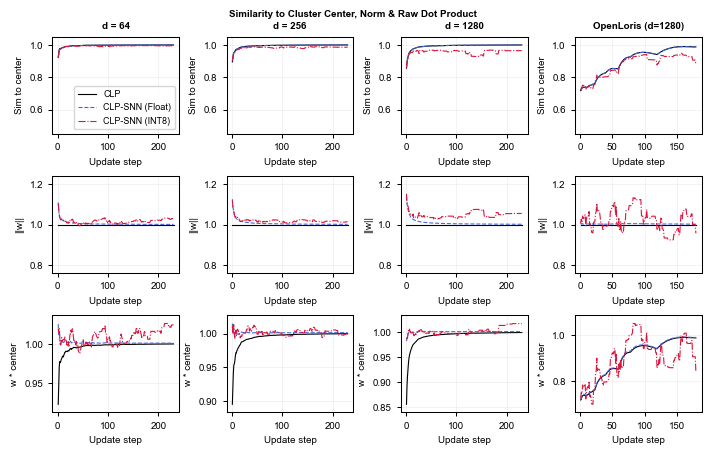

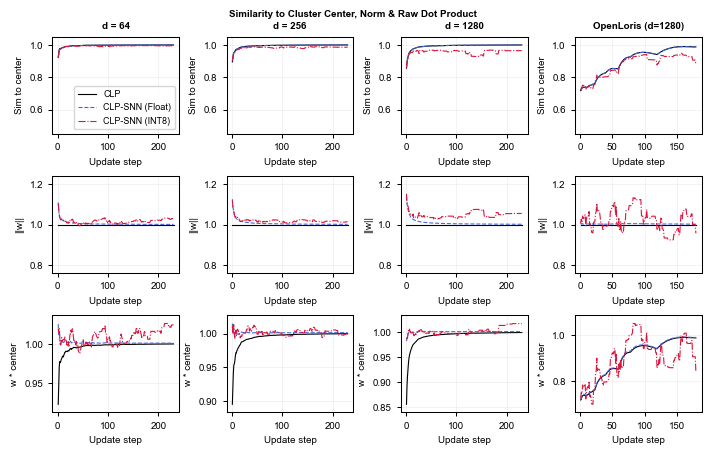

Saved images/self_norm_analysis.{pdf,png}


In [13]:
colors     = {'A': 'black', 'B': 'royalblue', 'F': 'crimson'}
labels     = {'A': 'CLP', 'B': 'CLP-SNN (Float)', 'F': 'CLP-SNN (INT8)'}
linestyles = {'A': '-', 'B': '--', 'F': '-.'}

row_keys   = [('sim_A', 'sim_B', 'sim_F'),
              ('norm_A', 'norm_B', 'norm_F'),
              ('raw_sim_A', 'raw_sim_B', 'raw_sim_F')]
row_ylims  = [(0.5, 1.0), (0.8, 1.2), None]
row_labels = ['Sim to center', '||w||', 'w * center']

fig, axes = plt.subplots(3, 4, figsize=(7.087, 4.5))
fig.patch.set_facecolor('white')

for row, (keys, ylim_hint, ylabel) in enumerate(zip(row_keys, row_ylims, row_labels)):
    kA, kB, kF = keys
    for col, dim in enumerate(DIMENSIONS):
        ax = axes[row, col]
        res = synth_results[dim]
        steps = np.arange(1, len(res[kA]) + 1)
        for var, k in zip(['A', 'B', 'F'], [kA, kB, kF]):
            ax.plot(steps, res[k], color=colors[var], lw=0.8, ls=linestyles[var],
                    label=labels[var] if (row == 0 and col == 0) else None)
        if ylim_hint is not None:
            lo, hi = ylim_hint
            ax.set_ylim([lo - (hi - lo) * 0.1, hi + (hi - lo) * 0.1])
        else:
            vals = np.concatenate([res[kA], res[kB], res[kF]])
            v_lo, v_hi = float(vals.min()), float(vals.max())
            m = (v_hi - v_lo) * 0.1 if v_hi > v_lo else 0.1
            ax.set_ylim([v_lo - m, v_hi + m])
        if row == 0:
            ax.set_title(f'd = {dim}', fontsize=7, fontweight='bold')
        ax.set_xlabel('Update step', fontsize=7)
        ax.set_ylabel(ylabel, fontsize=7)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        if row == 0 and col == 0:
            ax.legend(fontsize=6.5, loc='lower right', ncol=1)
    ax_ol = axes[row, 3]
    if ol_result is not None:
        steps_ol = np.arange(1, len(ol_result[kA]) + 1)
        for var, k in zip(['A', 'B', 'F'], [kA, kB, kF]):
            ax_ol.plot(steps_ol, ol_result[k], color=colors[var], lw=0.8, ls=linestyles[var])
        if ylim_hint is not None:
            lo, hi = ylim_hint
            ax_ol.set_ylim([lo - (hi - lo) * 0.1, hi + (hi - lo) * 0.1])
        else:
            vals = np.concatenate([ol_result[kA], ol_result[kB], ol_result[kF]])
            v_lo, v_hi = float(vals.min()), float(vals.max())
            m = (v_hi - v_lo) * 0.1 if v_hi > v_lo else 0.1
            ax_ol.set_ylim([v_lo - m, v_hi + m])
    else:
        ax_ol.text(0.5, 0.5, 'data not found', ha='center', va='center',
                   transform=ax_ol.transAxes, fontsize=7, color='gray')
    if row == 0:
        ax_ol.set_title('OpenLoris (d=1280)', fontsize=7, fontweight='bold')
    ax_ol.set_xlabel('Update step', fontsize=7)
    ax_ol.set_ylabel(ylabel, fontsize=7)
    ax_ol.grid(True, alpha=0.2, linewidth=0.5)

fig.suptitle('Similarity to Cluster Center, Norm & Raw Dot Product', fontsize=7, fontweight='bold')
plt.tight_layout(pad=0.6, h_pad=1.0, w_pad=0.5)
for ext in ('pdf', 'png'):
    plt.savefig(IMAGES_DIR / f'self_norm_analysis.{ext}', format=ext, bbox_inches='tight')
plt.show()
print('Saved images/self_norm_analysis.{pdf,png}')

## Sigma Sensitivity Analysis (Supplemental Fig. S2)

Shows how each variant responds to cluster tightness across two dimensions
(d = 128, 1280) and four sigma levels (Very Tight through Large).
Darker shades correspond to tighter clusters (smaller sigma).

The full reference implementation is in `analysis/sigma_sensitivity_analysis.py`.

  d=128, Very Tight: done
  d=128, Tight: done
  d=128, Medium: done
  d=128, Large: done
  d=1280, Very Tight: done
  d=1280, Tight: done
  d=1280, Medium: done
  d=1280, Large: done


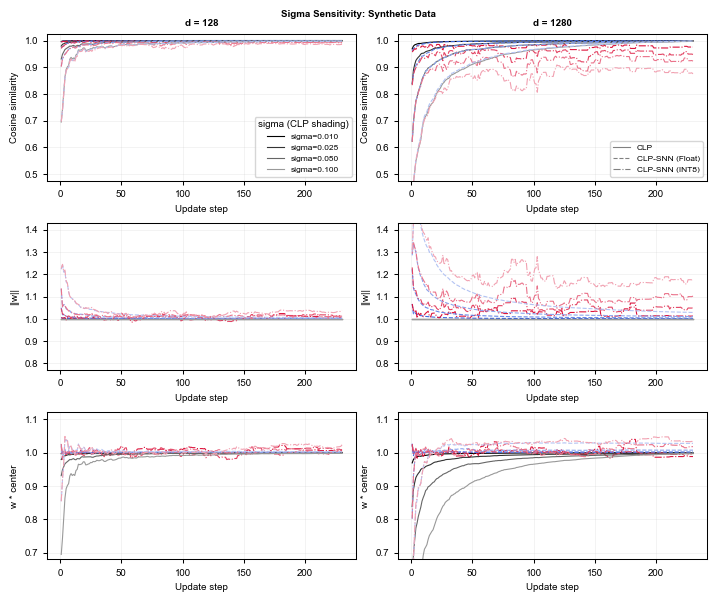

Saved images/sigma_sensitivity_analysis.{pdf,png}


In [14]:
import matplotlib.colors as mcolors

# ---- Config ------------------------------------------------------------------
DIMENSIONS_SS = [128, 1280]
N_SYNTH_SS    = 230
SEED_SS       = 0
ALPHA_MIN_SS  = 0
G_INC_SS      = 0.2   # slower decay than Fig. S1 to spread sigma effect

SIGMA_LABELS = ['Very Tight', 'Tight', 'Medium', 'Large']
SIGMAS = {
    'Very Tight': 0.010,
    'Tight':      0.025,
    'Medium':     0.050,
    'Large':      0.100,
}

# ---- Run experiments ---------------------------------------------------------
ss_results = {}
for dim in DIMENSIONS_SS:
    for sigma_label in SIGMA_LABELS:
        sigma = SIGMAS[sigma_label]
        rng = np.random.default_rng(SEED_SS + dim + hash(sigma_label) % 100)
        centre = rng.standard_normal(dim)
        centre /= np.linalg.norm(centre)
        samples = centre + sigma * rng.standard_normal((N_SYNTH_SS + 1, dim))
        samples /= np.linalg.norm(samples, axis=1, keepdims=True)
        ss_results[(dim, sigma_label)] = run_with_center_similarity(
            samples, alpha_min=ALPHA_MIN_SS, rng_seed=SEED_SS, g_inc=G_INC_SS)
        print(f'  d={dim}, {sigma_label}: done')

# ---- Plotting ----------------------------------------------------------------
def shade_color(color, idx, n):
    c = mcolors.to_rgb(color)
    blend = idx / (n - 1) * 0.6 if n > 1 else 0.3
    return tuple(c[i] + (1 - c[i]) * blend for i in range(3))


base_colors = {'A': 'black', 'B': 'royalblue', 'F': 'crimson'}
linestyles  = {'A': '-',     'B': '--',         'F': '-.'}

row_keys   = [('sim_A',     'sim_B',     'sim_F'),
              ('norm_A',    'norm_B',    'norm_F'),
              ('raw_sim_A', 'raw_sim_B', 'raw_sim_F')]
row_labels = ['Cosine similarity', '||w||', 'w * center']
row_ylims  = [(0.5, 1.0), (0.8, 1.4), (0.7, 1.1)]

fig, axes = plt.subplots(3, 2, figsize=(7.087, 6.0))
fig.patch.set_facecolor('white')

for row, (keys, ylabel, ylim) in enumerate(zip(row_keys, row_labels, row_ylims)):
    kA, kB, kF = keys
    for col, dim in enumerate(DIMENSIONS_SS):
        ax = axes[row, col]
        for sigma_idx, sigma_label in enumerate(SIGMA_LABELS):
            res = ss_results[(dim, sigma_label)]
            steps = np.arange(1, len(res[kA]) + 1)
            sv = SIGMAS[sigma_label]
            for var, k in zip(['A', 'B', 'F'], [kA, kB, kF]):
                c = shade_color(base_colors[var], sigma_idx, len(SIGMA_LABELS))
                label = None
                if row == 0 and col == 0 and var == 'A':
                    label = f'sigma={sv:.3f}'
                ax.plot(steps, res[k], color=c, lw=0.8, ls=linestyles[var], label=label)
        lo, hi = ylim
        ax.set_ylim([lo - (hi - lo) * 0.05, hi + (hi - lo) * 0.05])
        if row == 0:
            ax.set_title(f'd = {dim}', fontsize=7, fontweight='bold')
        ax.set_xlabel('Update step', fontsize=7)
        ax.set_ylabel(ylabel, fontsize=7)
        ax.grid(True, alpha=0.2, linewidth=0.5)

# Sigma legend (shaded black lines, top-left panel)
axes[0, 0].legend(fontsize=6, loc='lower right', title='sigma (CLP shading)')

# Variant legend (line style, separate)
from matplotlib.lines import Line2D
variant_legend = [
    Line2D([0], [0], color='gray', lw=0.8, ls='-',  label='CLP'),
    Line2D([0], [0], color='gray', lw=0.8, ls='--', label='CLP-SNN (Float)'),
    Line2D([0], [0], color='gray', lw=0.8, ls='-.', label='CLP-SNN (INT8)'),
]
axes[0, 1].legend(handles=variant_legend, fontsize=6, loc='lower right')

fig.suptitle('Sigma Sensitivity: Synthetic Data', fontsize=7, fontweight='bold')
plt.tight_layout(pad=0.6, h_pad=1.0, w_pad=0.5)
for ext in ('pdf', 'png'):
    plt.savefig(IMAGES_DIR / f'sigma_sensitivity_analysis.{ext}', format=ext, bbox_inches='tight')
plt.show()
print('Saved images/sigma_sensitivity_analysis.{pdf,png}')